# DESeq2 analysis on Jurkat essential screen for comparison

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os,sys
import pandas as pd
import numpy as np
import scanpy as sc
import anndata
import scipy
import pertpy

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

sys.path.append('../')
from DE_analysis_utils import *

/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/

## Prepare Pseudobulk for each gem_group in Jurkat

On comino (to run gem_groups in parallel)
```bash
for gem_group in {1..56}; do sbatch --gres=gpu:1 --mem=10G --wrap="PYTHONNOUSERSITE=1 /home/emmadann/miniforge3/envs/gwt_de/bin/python Jurkat_DE/jurkat_make_pseudobulk.py --gem_group ${gem_group}"; done
```

## Load Pseudobulk for each gem_group

In [3]:
import glob
pbulk_files = glob.glob('/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/tmp/Jurkat_essential_filt_pseudobulk_gemgroup_*')
pbulk_adata_list = []
from tqdm.notebook import tqdm
for f in tqdm(pbulk_files, desc="Processing gem_groups"):
    pbulk_batch_adata = anndata.read_h5ad(f)
    pbulk_batch_adata.layers['sum'] = scipy.sparse.csr_matrix(pbulk_batch_adata.layers['sum'])
    pbulk_adata_list.append(pbulk_batch_adata)

Processing gem_groups:   0%|          | 0/55 [00:00<?, ?it/s]

In [4]:
# Concatenate all pseudobulk AnnData objects
pbulk_adata = anndata.concat(pbulk_adata_list, join='outer')
print('Saving...')
pbulk_adata.write_h5ad('/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/Jurkat_essential_filt_pseudobulk.h5ad')

Saving...


## DE analysis with DESeq2

In [5]:
# Find perturbations with sufficient number of cells
jurkat_adata = anndata.experimental.read_lazy('/mnt/oak/users/emma/data/wesvae-data/Jurkat_essential.h5ad', load_annotation_index=True)
obs_df = jurkat_adata.obs.to_dataframe()

In [6]:
n_cells_perturb = obs_df[['gem_group', 'gene']].value_counts().reset_index()
n_cells_perturb = n_cells_perturb.rename({'count':'n_cells'}, axis=1)

In [7]:
pbulk_adata = sc.read_h5ad('/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/Jurkat_essential_filt_pseudobulk.h5ad')

In [8]:
obs_names = pbulk_adata.obs_names.copy()
obs_df = pd.merge(pbulk_adata.obs, n_cells_perturb)
obs_df.index = obs_names
pbulk_adata.obs = obs_df.copy()

/tmp/ipykernel_3674101/2511055951.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_n_cells = n_cells_perturb.groupby('gene')['n_cells'].mean()


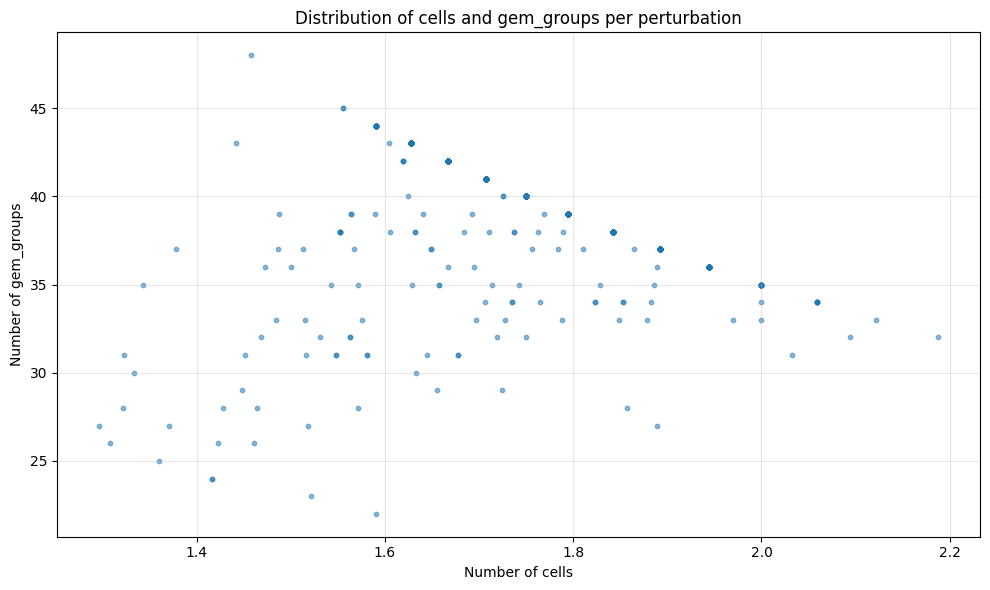

In [9]:
sum_n_cells = n_cells_perturb.groupby('gene')['n_cells'].mean()
n_gem_groups = pbulk_adata.obs.value_counts('gene', ascending=True)
pl_df = pd.concat([n_gem_groups, sum_n_cells], axis=1)
pl_df = pl_df.drop('non-targeting')
plt.figure(figsize=(10, 6))
plt.scatter(pl_df['n_cells'], pl_df['count'], alpha=0.5, s=10)
plt.xlabel('Number of cells')
plt.ylabel('Number of gem_groups')
plt.title('Distribution of cells and gem_groups per perturbation')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
pbulk_adata = pbulk_adata[pbulk_adata.obs['n_cells'] > 2].copy()

/tmp/ipykernel_3674101/233688660.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_n_cells = n_cells_perturb.groupby('gene')['n_cells'].sum()


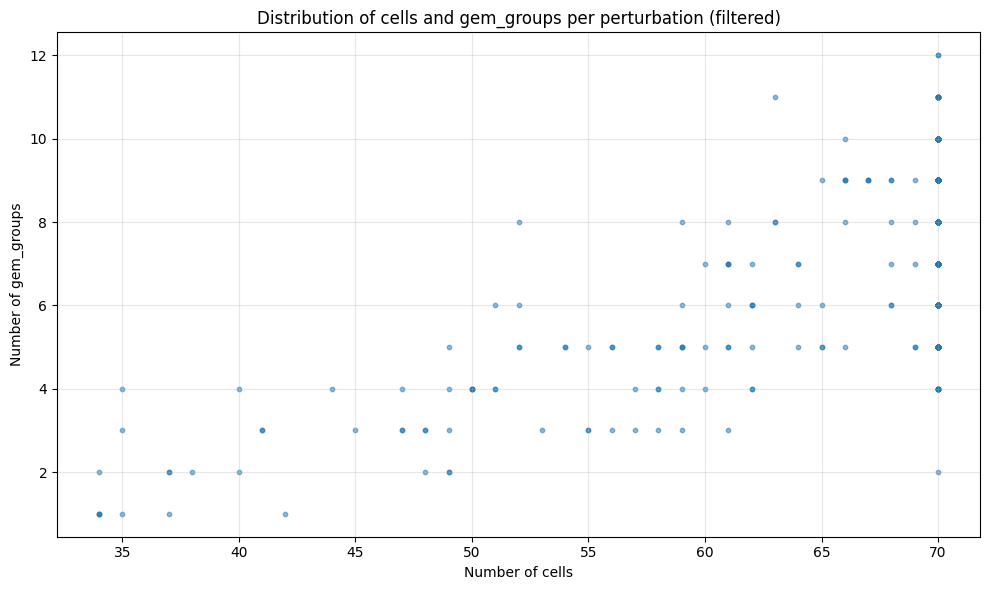

In [11]:
sum_n_cells = n_cells_perturb.groupby('gene')['n_cells'].sum()
n_gem_groups = pbulk_adata.obs.value_counts('gene', ascending=True)
pl_df = pd.concat([n_gem_groups, sum_n_cells], axis=1)
pl_df = pl_df.drop('non-targeting')
plt.figure(figsize=(10, 6))
plt.scatter(pl_df['n_cells'], pl_df['count'], alpha=0.5, s=10)
plt.xlabel('Number of cells')
plt.ylabel('Number of gem_groups')
plt.title('Distribution of cells and gem_groups per perturbation (filtered)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
pbulk_adata.write_h5ad('/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/Jurkat_essential_filt_pseudobulk.for_DE.h5ad')

### Split perturbations into chunks

In [13]:
all_targets = pbulk_adata.obs['gene'].unique().tolist()
len(all_targets)

452

In [14]:
chunk_size = 75
chunk_split_seed = 24387
all_targets = pbulk_adata.obs['gene'].unique().tolist()

# Randomize targets before splitting (without replacement)
np.random.seed(chunk_split_seed)
np.random.shuffle(all_targets)

# Split all_targets into groups based on chunk_size
target_chunks = [all_targets[i:i+chunk_size] for i in range(0, len(all_targets), chunk_size)]

# Initialize a binary matrix with zeros
target_chunk_matrix = pd.DataFrame(0, 
                                index=all_targets, 
                                columns=[f'chunk_{i}' for i in range(len(target_chunks))])

# Fill the matrix with 1s for each target in its respective chunk
for chunk_idx, chunk in enumerate(target_chunks):
    target_chunk_matrix.loc[chunk, f'chunk_{chunk_idx}'] = 1

target_chunk_matrix.to_csv('/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/Jurkat_essential_filt_pseudobulk.target2chunk.csv')

In [15]:
target_chunk_matrix.shape

(452, 7)

## Run DESeq2 in chunks of perturbations

On comino:
```bash
n_chunks=$(python -c "import pandas as pd; m=pd.read_csv('/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/Jurkat_essential_filt_pseudobulk.target2chunk.csv', index_col=0); print(m.shape[1]-1)")
for chunk in $(seq 0 $n_chunks); do sbatch --mem=16G --wrap="python jurkat_run_DE_chunk.py --chunk_ix ${chunk}"; done
```

## Merge DESeq2 results

In [16]:
sys.path.append('../')
from DE_analysis_utils import *

In [17]:
def parse_DE_results_2_adata(df):
    all_dfs = {}
    for stat in ['baseMean', 'log_fc', 'lfcSE', 'p_value','adj_p_value']:
        stat_df = df.pivot(values=stat, columns='variable', index='target_contrast')
        all_dfs[stat] = stat_df

    DE_anndata = anndata.AnnData(
        layers = all_dfs.copy()
    )

    DE_anndata.obs_names = all_dfs['log_fc'].index.tolist()
    DE_anndata.var_names = all_dfs['log_fc'].columns.tolist()
    DE_anndata.obs = df[['target_contrast', 'culture_condition']].drop_duplicates().set_index('target_contrast').loc[DE_anndata.obs_names]
    DE_anndata.obs['target_contrast'] = DE_anndata.obs_names.values
    DE_anndata.obs_names = DE_anndata.obs['target_contrast'] + '_' + DE_anndata.obs['culture_condition']
    return(DE_anndata)

In [18]:
import glob
import pandas as pd

# Get all chunk result files
de_results_files = glob.glob('/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/tmp/DE_results.chunk_*.csv.gz')

de_results_adatas = []

for file in tqdm(de_results_files, desc="Processing DE result files"):
    try:
        df = pd.read_csv(file, compression='gzip', index_col=0)
        df = df.rename({'contrast': 'target_contrast'}, axis=1)
        de_results_adatas.append(parse_DE_results_2_adata(df))
    except EOFError:
        continue

Processing DE result files: 100%|██████████| 7/7 [00:03<00:00,  1.75it/s]


In [19]:
combined_de_adata = anndata.concat(de_results_adatas, label='chunk')
combined_de_adata.obs_names = combined_de_adata.obs_names.str.split('-').str[0]
assert combined_de_adata.obs_names.is_unique
combined_de_adata.obs['target_contrast_gene_name'] = combined_de_adata.obs['target_contrast'].copy()

In [20]:
n_cells_perturb = n_cells_perturb.groupby('gene')['n_cells'].sum().reset_index()
# Add n cells per perturbation
obs_names = combined_de_adata.obs_names.copy()
obs_df = pd.merge(combined_de_adata.obs, n_cells_perturb.rename({'gene':'target_contrast', 'n_cells':'n_cells_target'}, axis=1))
obs_df.index = obs_names
combined_de_adata.obs = obs_df.copy()

/tmp/ipykernel_3674101/1385069172.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_cells_perturb = n_cells_perturb.groupby('gene')['n_cells'].sum().reset_index()


In [21]:
datadir = '/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/'
combined_de_adata.write_h5ad(datadir + 'Jurkat.merged_DE_results.h5ad')

In [3]:
datadir = '/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/'
combined_de_adata = sc.read_h5ad(datadir + 'Jurkat.merged_DE_results.h5ad')

In [4]:
combined_de_adata

AnnData object with n_obs × n_vars = 451 × 3899
    obs: 'culture_condition', 'target_contrast', 'chunk', 'target_contrast_gene_name', 'n_cells_target'
    layers: 'adj_p_value', 'baseMean', 'lfcSE', 'log_fc', 'p_value'

Get stats

In [5]:
jurkat_stats = get_de_stats(combined_de_adata, signif_col = 'adj_p_value', effect_col = 'log_fc')
effect_in_jurkat_targets = jurkat_stats[jurkat_stats['n_total_de_genes'] > 0].target_name.tolist()
combined_de_adata.var['gene_name'] = combined_de_adata.var_names.values

In [6]:
len(effect_in_jurkat_targets)

93

## Run MASH with CD4T cell results

In [7]:
datadir = '/mnt/oak/users/emma/data/GWT/CD4i_final/'
experiment_name = 'CD4i_final'
adata_de = sc.read_h5ad(datadir + f'/DE_results_all_confounders/{experiment_name}.merged_DE_results.h5ad')
DE_stats = pd.read_csv(datadir + f'/DE_results_all_confounders/DE_summary_stats_per_target.csv', index_col=0)

Run MASH

In [8]:
import pymash

In [9]:
# Split effect_in_jurkat_targets into 10 bins of randomly sampled values
np.random.seed(42)  # For reproducibility
shuffled_targets = np.random.permutation(effect_in_jurkat_targets)
binned_targets = np.array_split(shuffled_targets, 10)

In [10]:
# Train on first bin
train_targets = binned_targets[0]
# Fit model on all other bins
test_targets = binned_targets[1:]

In [11]:
# Train MASH model on first bin
Jurkat_results_long = get_DE_results_long(combined_de_adata, targets=train_targets, effect_estimates =['log_fc', 'lfcSE'])
Jurkat_results_long['test'] = Jurkat_results_long['target_contrast'].astype(str) + '_' + Jurkat_results_long['gene'].astype(str)
Tcells_results_long = get_DE_results_long(adata_de, targets=train_targets, effect_estimates =['log_fc', 'lfcSE'], gene_id_col='gene_ids')
Tcells_results_long['test'] = Tcells_results_long['target_contrast_gene_name'].astype(str) + '_' + Tcells_results_long['gene_ids'].astype(str)
Tcells_Bhat = Tcells_results_long.pivot(index='test', values='log_fc', columns='culture_condition')
Tcells_Shat = Tcells_results_long.pivot(index='test', values='lfcSE', columns='culture_condition')
Bhat = pd.concat([Jurkat_results_long.set_index('test')['log_fc'], Tcells_Bhat], axis=1).dropna().T
Shat = pd.concat([Jurkat_results_long.set_index('test')['lfcSE'], Tcells_Shat], axis=1).dropna().T

In [12]:
Bhat.head()

test,COX15_ENSG00000000460,COX15_ENSG00000001084,COX15_ENSG00000001461,COX15_ENSG00000001561,COX15_ENSG00000001629,COX15_ENSG00000001631,COX15_ENSG00000002586,COX15_ENSG00000002822,COX15_ENSG00000002834,COX15_ENSG00000003393,...,ZC3H3_ENSG00000276045,ZC3H3_ENSG00000276234,ZC3H3_ENSG00000277161,ZC3H3_ENSG00000277258,ZC3H3_ENSG00000277972,ZC3H3_ENSG00000278023,ZC3H3_ENSG00000278129,ZC3H3_ENSG00000278259,ZC3H3_ENSG00000278540,ZC3H3_ENSG00000285077
log_fc,-0.183092,-0.110786,-0.408997,-0.497219,0.402853,-0.034105,-0.139076,-0.200515,-0.074247,0.915145,...,0.023141,0.612997,1.434210,-0.493428,-0.171435,1.263871,-0.280956,0.011512,0.581550,0.677131
Rest,0.143478,0.274147,-0.123430,0.119036,0.177461,0.139063,-0.299602,0.063370,-0.149493,-0.192088,...,-0.075653,0.136927,0.823958,-0.039472,-0.108727,1.448364,0.128183,-0.336329,-0.232987,0.710715
Stim8hr,0.053128,0.015945,0.017805,0.084829,-0.031123,0.030983,-0.085514,-0.113337,-0.059082,-0.220831,...,-0.142657,0.138939,0.663993,-0.230271,-0.283464,1.250082,0.127360,-0.082212,-0.214373,0.122943
Stim48hr,0.093013,0.085679,0.035300,-0.297638,-0.174755,0.052462,-0.168813,-0.109010,0.107139,-0.107271,...,0.163207,-0.000995,0.627139,0.691232,-0.132093,0.381473,-0.026972,-0.281204,0.046245,-0.308051


In [13]:
mash = pymash.tl.Mash(Bhat, Shat)
strong_tests = mash.get_strong_subset(thresh=0.01)
random_tests = mash.get_random_subset(n=20000)

Ulist_canonical = pymash.covariance_utils.cov_canonical(mash)
mash.extend_Ulist(Ulist_canonical, overwrite=False)

# Subset to strong tests
mash_strong = mash.copy()
mash_strong.adata = mash_strong.adata[:, random_tests].copy()

# Get PC based covariances
Ulist_pca = pymash.covariance_utils.cov_pca(mash_strong)
Ulist_ed = pymash.covariance_utils.cov_ed(mash_strong, Ulist_pca)
mash.extend_Ulist(Ulist_ed)

# Fit on subset of tests
mash.fit(subset_vars=random_tests, return_full=False)

# Get posterior for all tests
mash.predict()

all_res_df = mash.get_results()

R[write to console]: Loading required package: ashr



 - Computing 20000 x 337 likelihood matrix.
 - Likelihood calculations took 1.99 seconds.
 - Fitting model with 337 mixture components.
 - Model fitting took 4.75 seconds.
 - Computing 37910 x 337 likelihood matrix.
 - Likelihood calculations took 3.48 seconds.
 - Computing posterior matrices.
 - Computation allocated took 0.58 seconds.


In [14]:
all_res_df.shape

(151640, 8)

In [15]:
# Fit mash on all other bins
from tqdm.notebook import tqdm
for ts in tqdm(test_targets, desc="Processing test targets"):
    Jurkat_results_long = get_DE_results_long(combined_de_adata, targets=ts, effect_estimates =['log_fc', 'lfcSE'])
    Jurkat_results_long['test'] = Jurkat_results_long['target_contrast'].astype(str) + '_' + Jurkat_results_long['gene'].astype(str)
    Tcells_results_long = get_DE_results_long(adata_de, targets=ts, effect_estimates =['log_fc', 'lfcSE'], gene_id_col='gene_ids')
    Tcells_results_long['test'] = Tcells_results_long['target_contrast_gene_name'].astype(str) + '_' + Tcells_results_long['gene_ids'].astype(str)
    Tcells_Bhat = Tcells_results_long.pivot(index='test', values='log_fc', columns='culture_condition')
    Tcells_Shat = Tcells_results_long.pivot(index='test', values='lfcSE', columns='culture_condition')
    Bhat = pd.concat([Jurkat_results_long.set_index('test')['log_fc'], Tcells_Bhat], axis=1).dropna().T
    Shat = pd.concat([Jurkat_results_long.set_index('test')['lfcSE'], Tcells_Shat], axis=1).dropna().T

    # Predict on test targets from model trained on train targets
    mash_test = pymash.tl.Mash(Bhat, Shat)
    mash_test.extend_Ulist(mash.get_Ulist())
    mash_test.fitted_g = mash.fitted_g.copy()
    mash_test.predict()
    ts_res_df = mash_test.get_results()
    all_res_df = pd.concat([all_res_df, ts_res_df])

Processing test targets:   0%|          | 0/9 [00:00<?, ?it/s]

 - Computing 37910 x 337 likelihood matrix.
 - Likelihood calculations took 3.47 seconds.
 - Computing posterior matrices.
 - Computation allocated took 0.58 seconds.
 - Computing 37910 x 337 likelihood matrix.
 - Likelihood calculations took 3.66 seconds.
 - Computing posterior matrices.
 - Computation allocated took 0.59 seconds.
 - Computing 30328 x 337 likelihood matrix.
 - Likelihood calculations took 2.86 seconds.
 - Computing posterior matrices.
 - Computation allocated took 0.50 seconds.
 - Computing 34119 x 337 likelihood matrix.
 - Likelihood calculations took 3.26 seconds.
 - Computing posterior matrices.
 - Computation allocated took 0.52 seconds.
 - Computing 34119 x 337 likelihood matrix.
 - Likelihood calculations took 3.25 seconds.
 - Computing posterior matrices.
 - Computation allocated took 0.52 seconds.
 - Computing 34119 x 337 likelihood matrix.
 - Likelihood calculations took 3.26 seconds.
 - Computing posterior matrices.
 - Computation allocated took 0.52 seconds

In [16]:
all_res_df.to_parquet('/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/MASH_comparison_results.parquet')

In [17]:
all_res_df = pd.read_parquet('/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/MASH_comparison_results.parquet')
all_res_df.head()

,index,test,model_key,Bhat,Shat,PosteriorMean,PosteriorSD,lfsr
0,log_fc,COX15_ENSG00000000460,None,-0.183092,0.507352,0.026841,0.047164,0.472177
1,log_fc,COX15_ENSG00000001084,None,-0.110786,0.462861,0.052323,0.057359,0.231188
2,log_fc,COX15_ENSG00000001461,None,-0.408997,0.643715,-0.009009,0.045615,0.695630
3,log_fc,COX15_ENSG00000001561,None,-0.497219,0.699550,-0.002087,0.050939,0.751514
4,log_fc,COX15_ENSG00000001629,None,0.402853,0.419428,0.008910,0.045043,0.699733


In [18]:
all_res_df['target_contrast_gene_name'] = all_res_df['test'].str.split("_").str[0]

In [21]:
all_res_df[all_res_df['lfsr'] < 0.05].value_counts('index')

index
Stim48hr    21831
Stim8hr     20788
Rest        19487
log_fc       4849
Name: count, dtype: int64